
Visualizing a Mel spectrogram

Running simple inference

# Setup & Installation

In [ ]:
!pip install git+https://github.com/openai/whisper.git
!pip install datasets torch librosa soundfile matplotlib accelerate peft bitsandbytes
!pip install transformers


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-598vr7u3
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-598vr7u3
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Imports and Config

In [ ]:
import whisper
import torch
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load model (choose "tiny", "base", "small", "medium", or "large")
model = whisper.load_model("small")
print("Whisper model loaded")



Whisper model loaded


# Load an Audio File
You can upload your own .wav or .mp3 file by running this first:

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload your audio file
audio_path = list(uploaded.keys())[0]
print(f" Using audio file: {audio_path}")



Saving test_audio.mp3 to test_audio (1).mp3
 Using audio file: test_audio (1).mp3


# Display the Mel Spectrogram

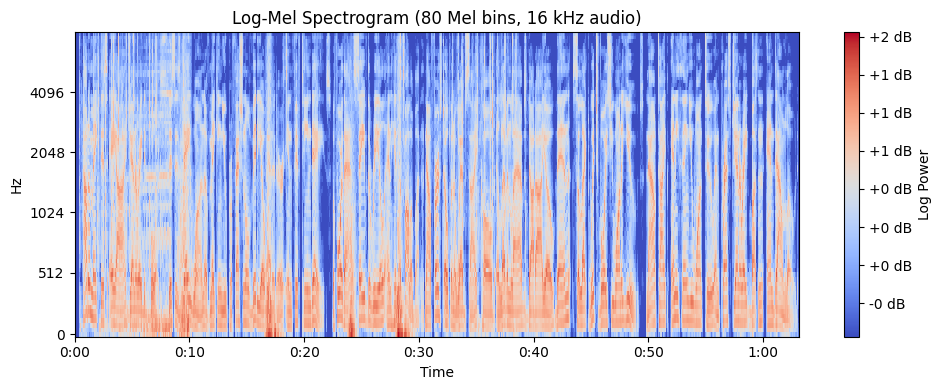

In [ ]:
# Load audio
audio, sr = librosa.load(audio_path, sr=16000)

# Compute log-Mel spectrogram
# Load audio file at 16 kHz sample rate (Whisper expects 16,000 samples per second)
#Samples are just numbers — tiny measurements of air pressure (sound wave amplitude) at each moment in time.

#Each number tells how “high” or “low” the wave is at that instant.
# -------------------------------------------------------------------------------
#  "kHz" stands for kilohertz (1,000 samples per second)
#    - 8 kHz  → 8,000 samples per second (used in phone calls)
#    - 16 kHz → 16,000 samples per second (used in speech models like Whisper)
#    - 44.1 kHz → 44,100 samples per second (CD-quality audio)
#    Think of it like "frames per second" for sound — higher kHz = more detail.
# -------------------------------------------------------------------------------
audio, sr = librosa.load(audio_path, sr=16000). # 16,000 air pressure changes per second

# Compute the log-Mel spectrogram
# -------------------------------------------------------------------------------
# whisper.log_mel_spectrogram() internally:
#  - Splits the audio into short overlapping windows (frames)
#  - Applies STFT (Short-Time Fourier Transform) → frequency content
#  - Converts frequencies to the Mel scale (how humans perceive pitch)
#  - Applies log scaling → compresses loudness range
#  - Output: 80 Mel channels × time steps (default setting for Whisper)
# -------------------------------------------------------------------------------
mel = whisper.log_mel_spectrogram(torch.tensor(audio))

# Visualize the Mel spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel.numpy(),
    sr=sr,
    x_axis="time",    # horizontal axis → time progression
    y_axis="mel"      # vertical axis → frequency on Mel scale
)
plt.colorbar(format="%+2.0f dB", label="Log Power")  # color = intensity (loudness)
plt.title("Log-Mel Spectrogram (80 Mel bins, 16 kHz audio)")
plt.tight_layout()
plt.show()


# Run Whisper Inference

In [ ]:
# Transcribe
result = model.transcribe(audio_path)
print(" Transcription:")
print(result["text"])


 Transcription:
 How to make this AI generated voice. This is day one of making you professional video editor in 15 days. Before that, save the reel and hit the follow button. Now first open a website called 11Labs.io, then select which voice you want to use. Now type anything you want to and press generate button and download.
